**Summary:** This work employs out-of-distribution (OOD) analysis to evaluate the performance of machine learning models for polarization prediction. In the first stage, a Gaussian Process (GP) model was developed by optimizing its key hyperparameters, including the length scale, coefficient, noise level, and kernel type. The optimized hyperparameters were then used to train the GP model for polarization prediction. In parallel, a Multilayer Perceptron (MLP) model was also trained for the same task. After both models were developed, OOD analysis was conducted by systematically varying the frequency beyond the range used during training, both above and below the frequency threshold. This approach enabled a detailed comparison of the predictive performance and generalization behavior of the GP and MLP models under OOD conditions. In the final stage, a generalized model was constructed using Gaussian Process Approximation (GPA) by combining data from three different sample IDs.


# GP: Hyperparameter optimization

In [18]:
# Hyper-parameters GP (No Bound)
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
import pandas as pd

class GPHyperOpt:
    def __init__(self, kernel="laplace"):
        self.kernel = kernel
        self.log_lengthscale = tf.Variable(np.log(1.0), dtype=tf.float64)  # Initial guess
        self.log_coefficient = tf.Variable(np.log(1.0), dtype=tf.float64)  # Initial guess
        self.log_noise = tf.Variable(np.log(0.01), dtype=tf.float64)       # Initial guess
        self.scaler_X = None
        self.scaler_y = None
        self.X_train = None
        self.y_train = None

    def _covariance(self, x1, x2, noise=False):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)
        l = tf.exp(self.log_lengthscale)
        c = tf.exp(self.log_coefficient)

        if self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / l), axis=2)
            cov = c**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "eq":
            l2 = tf.reduce_sum((diff / l) ** 2, axis=2)
            cov = c**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff ** 2), axis=2)
            cov = c**2 / (1.0 + l2 / (l ** 2))
        else:
            raise ValueError("Unknown kernel")

        if noise:
            cov += tf.exp(self.log_noise) ** 2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train, methods):
        # Normalize
        self.scaler_X = StandardScaler()
        self.X_train = self.scaler_X.fit_transform(X_train)
        self.scaler_y = StandardScaler()
        self.y_train = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

        results = {}

        def nll(params):
            self.log_lengthscale.assign(params[0])
            self.log_coefficient.assign(params[1])
            self.log_noise.assign(params[2])
            K = self._covariance(self.X_train, self.X_train, noise=True)
            L = tf.linalg.cholesky(K)
            alpha = tf.linalg.cholesky_solve(L, self.y_train[:, None])
            nll_value = (
                0.5 * tf.matmul(tf.transpose(self.y_train[:, None]), alpha)
                + tf.reduce_sum(tf.math.log(tf.linalg.diag_part(L)))
                + 0.5 * len(self.y_train) * np.log(2 * np.pi)
            )
            return nll_value.numpy().flatten()[0]

        x0 = [self.log_lengthscale.numpy(), self.log_coefficient.numpy(), self.log_noise.numpy()]

        for method in methods:
            try:
                res = minimize(nll, x0, method=method)
                results[method] = {
                "loss": res.fun,                 # store the minimized negative log-likelihood
                "hyperparameters": np.exp(res.x) # store the optimized hyperparameters
                }
            except Exception as e:
                 results[method] = f"Failed ({e})"


        return results


# ---------------- Main ----------------
if __name__ == "__main__":
    # Load and prepare data
    data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
    filtered_data = data[data["SampleID"] == "(P07)"]
    X = filtered_data[["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]].values
    y = filtered_data["polarization"].values

    # Split data
    dataset_size = X.shape[0]

    tf.random.set_seed(42)
    shuffled_indices = tf.random.shuffle(tf.range(dataset_size), seed=42)

    train_split = int(0.70 * dataset_size)
    val_split   = int(0.85 * dataset_size)  # 70% train + 15% val

    train_idx = shuffled_indices[:train_split]
    val_idx   = shuffled_indices[train_split:val_split]
    test_idx  = shuffled_indices[val_split:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val,   y_val   = X[val_idx],   y[val_idx]
    X_test,  y_test  = X[test_idx],  y[test_idx]

    # Optimization methods to compare
    methods = ["Powell", "Nelder-Mead", "L-BFGS-B", "CG", "COBYQA"]

    # Run for different kernels
    for kernel in ["laplace", "eq", "cauchy"]:
        print(f"\n{'='*60}\nKernel: {kernel.upper()}\n{'='*60}")
        gp = GPHyperOpt(kernel=kernel)
        results = gp.fit(X_train, y_train, methods)
        for method, info in results.items():
            if isinstance(info, dict):
                print(f"{method:12s} → Loss: {info['loss']:.4f} | Optimized hyperparameters (lengthscale, coefficient, noise): {info['hyperparameters']}")
            else:
                print(f"{method:12s} → {info}")


Kernel: LAPLACE
Powell       → Loss: -197.5860 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.58199965e+03 3.04952327e+01 1.18586651e-01]
Nelder-Mead  → Loss: -197.5865 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.60751272e+03 3.07586851e+01 1.18438379e-01]
L-BFGS-B     → Loss: -197.5730 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.21182664e+03 2.66507223e+01 1.18562381e-01]
CG           → Loss: -197.5851 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.47029037e+03 2.93848694e+01 1.18491254e-01]
COBYQA       → Loss: -197.5865 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.60760542e+03 3.07595470e+01 1.18438485e-01]

Kernel: EQ
Powell       → Loss: 913.7964 | Optimized hyperparameters (lengthscale, coefficient, noise): [4.31787551e-11 9.99949981e-01 1.00018210e-02]
Nelder-Mead  → Loss: -90.0414 | Optimized hyperparameters (lengthscale, coefficient, noise): [0.64571255 1.05720135 0.17701377

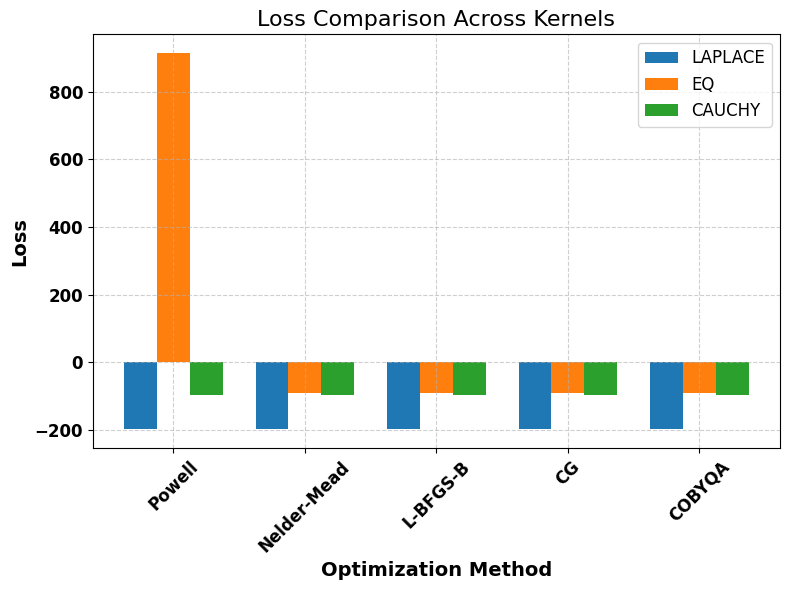

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# Apply your exact template formatting
# --------------------------------------------------
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# --------------------------------------------------
# Data
# --------------------------------------------------
methods = ["Powell", "Nelder-Mead", "L-BFGS-B", "CG", "COBYQA"]

laplace_loss = [-197.5860, -197.5865, -197.5730, -197.5851, -197.5865]
eq_loss      = [913.7964, -90.0414, -90.0414, -90.0414, -90.0414]
cauchy_loss  = [-96.1012, -95.9674, -96.1012, -96.4502, -96.4502]

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(methods))
width = 0.25

ax.bar(x - width, laplace_loss, width, label="LAPLACE")
ax.bar(x,         eq_loss,      width, label="EQ")
ax.bar(x + width, cauchy_loss,  width, label="CAUCHY")

ax.set_xlabel("Optimization Method", fontweight='bold')
ax.set_ylabel("Loss", fontweight='bold')
ax.set_title("Loss Comparison Across Kernels")

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45)

# Bold tick labels
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()

plt.tight_layout()
plt.show()


# GP Model development

In [2]:
# ------------------------
# 0. Imports
# ------------------------
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct

# ------------------------
# 1. GP Model Class
# ------------------------
class GPModelTF:
    def __init__(self, kernel="laplace", lengthscale=1.0, coefficient=1.0, noise=1e-2):
        self.kernel = kernel
        self.lengthscale = lengthscale
        self.coefficient = coefficient
        self.noise = noise
        self.scaler_X = None
        self.scaler_y = None
        self.X_train_norm = None
        self.y_train_norm = None

    def _covariance(self, x1, x2, noise=None):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)

        if self.kernel == "eq":
            l2 = tf.reduce_sum((diff / self.lengthscale)**2, axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / self.lengthscale), axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff / self.lengthscale)**2, axis=2)
            cov = self.coefficient**2 / (1.0 + l2)
        else:
            raise ValueError("Unknown kernel type")

        if noise is not None:
            cov += noise**2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train):
        self.scaler_X = StandardScaler()
        self.X_train_norm = self.scaler_X.fit_transform(X_train)

        self.scaler_y = StandardScaler()
        self.y_train_norm = self.scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

    def predict(self, X_new):
        X_new_norm = self.scaler_X.transform(X_new)
        Kdd = self._covariance(self.X_train_norm, self.X_train_norm, noise=self.noise)
        Kpd = self._covariance(X_new_norm, self.X_train_norm)
        Kpp = self._covariance(X_new_norm, X_new_norm)

        alpha = tf.linalg.solve(Kdd, tf.expand_dims(self.y_train_norm, axis=1))
        mean_norm = tf.matmul(Kpd, alpha)[:, 0]
        cov = Kpp - tf.matmul(Kpd, tf.linalg.solve(Kdd, tf.transpose(Kpd)))
        var_norm = tf.linalg.diag_part(cov)

        mean_orig = self.scaler_y.inverse_transform(mean_norm.numpy().reshape(-1, 1)).flatten()
        std_orig = (var_norm.numpy()**0.5) * self.scaler_y.scale_
        return mean_orig, std_orig

# ------------------------
# 2. Load and Prepare Data
# ------------------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
filtered_data = data[data['SampleID'] == '(P07)']

for col in ['start_time', 'end_time']:
    if col in filtered_data.columns:
        filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')

New_data = filtered_data[['uwave_freq', 'TGT:PT12:Target_Dose', 'scaler_calc1', 'polarization']]
X = New_data.iloc[:, 0:3].values
y = New_data.iloc[:, -1].values

# ------------------------
# 3. Train/Test Split
# ------------------------
dataset_size = X.shape[0]

tf.random.set_seed(42)
shuffled_indices = tf.random.shuffle(tf.range(dataset_size), seed=42)

train_split = int(0.70 * dataset_size)
val_split   = int(0.85 * dataset_size)  # 70% train + 15% val

train_idx = shuffled_indices[:train_split]
val_idx   = shuffled_indices[train_split:val_split]
test_idx  = shuffled_indices[val_split:]

X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# ------------------------
# 4. Fit GP Model
# ------------------------
gp_model = GPModelTF(kernel="laplace", lengthscale=1607.5127, coefficient=30.75, noise=0.11843) # LAPLACE L-BFGS-B

# ============================================================
# Kernel: LAPLACE
# ============================================================
# Powell       → Loss: -197.5860 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.58199965e+03 3.04952327e+01 1.18586651e-01]
# Nelder-Mead  → Loss: -197.5865 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.60751272e+03 3.07586851e+01 1.18438379e-01]
# L-BFGS-B     → Loss: -197.5730 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.21182664e+03 2.66507223e+01 1.18562381e-01]
# CG           → Loss: -197.5851 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.47029037e+03 2.93848694e+01 1.18491254e-01]
# COBYQA       → Loss: -197.5865 | Optimized hyperparameters (lengthscale, coefficient, noise): [1.60760542e+03 3.07595470e+01 1.18438485e-01]

gp_model.fit(X_train, y_train)
mean_pred, std_pred = gp_model.predict(X_test)

filtered_test = filtered_data.iloc[test_idx]
filtered_test['Polarization_Prediction'] = mean_pred
filtered_test['Polarization_Prediction_std'] = std_pred

if 'start_time' in filtered_test.columns:
    filtered_test = filtered_test.sort_values('start_time').reset_index(drop=True)

# ------------------------
# 5. R² Calculation
# ------------------------
r2 = r2_score(filtered_test['polarization'], filtered_test['Polarization_Prediction'])
print(f"R²: {r2:.3f}")



R²: 0.982


/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_22465/3398977139.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')
/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_22465/3398977139.py:79: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')
/var/folders/f7/ctknnb4x36jgpz3vdy9mhydc000_br/T/ipykernel_22465/3398977139.py:122: SettingWithCopyWarning: 

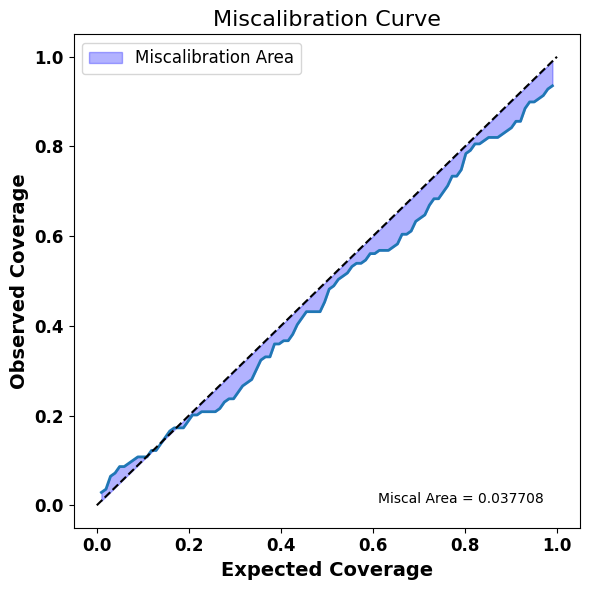

Miscalibration area: 0.03770763752634256


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 🔹 Global plotting style
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

def draw_miscalibration_curve(pred_mean, pred_std, y_true, n_bins=100):
    """
    Draws miscalibration curve with shaded miscalibration area
    and returns miscalibration area
    """

    # Expected coverage levels
    p_exp = np.linspace(0.01, 0.99, n_bins)
    p_obs = []

    for p in p_exp:
        z = norm.ppf((1 + p) / 2.0)
        inside = np.abs(y_true - pred_mean) <= z * pred_std
        p_obs.append(np.mean(inside))

    p_obs = np.array(p_obs)

    # ❗ Keep original calculation
    miscal = np.mean(np.abs(p_obs - p_exp))

    # Plot using ax object
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(p_exp, p_obs, linewidth=2)
    ax.plot([0, 1], [0, 1], "k--")

    ax.fill_between(
        p_exp,
        p_obs,
        p_exp,
        color="blue",
        alpha=0.3,
        label="Miscalibration Area"
    )

    ax.text(
        0.60, 0.05,
        f"Miscal Area = {miscal:.6f}",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    ax.set_xlabel("Expected Coverage", fontweight="bold")
    ax.set_ylabel("Observed Coverage", fontweight="bold")
    ax.set_title("Miscalibration Curve")
    ax.legend()

    # 🔹 Bold tick labels
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    plt.tight_layout()
    plt.show()

    return miscal


miscal = draw_miscalibration_curve(
    filtered_test['Polarization_Prediction'].values,
    filtered_test['Polarization_Prediction_std'].values,
    filtered_test['polarization'].values
)

print("Miscalibration area:", miscal)


R²: 0.982


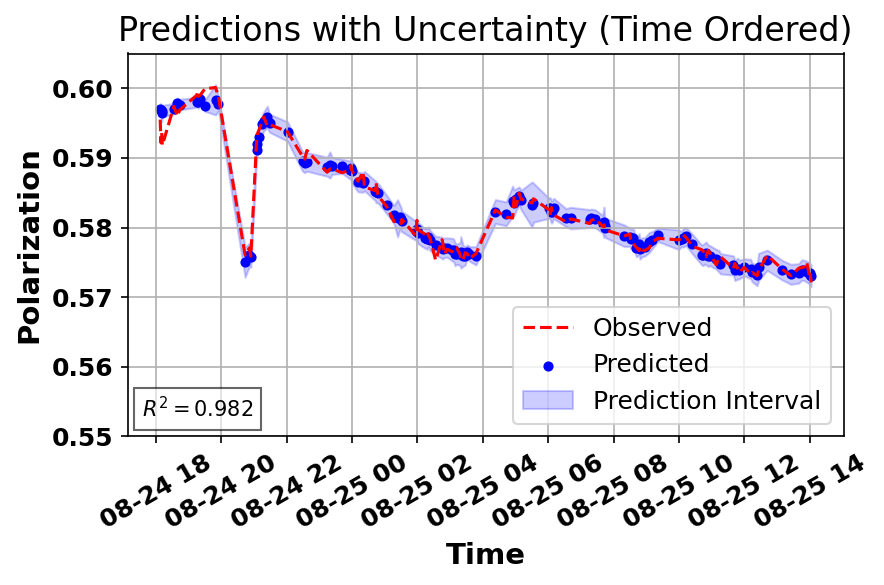

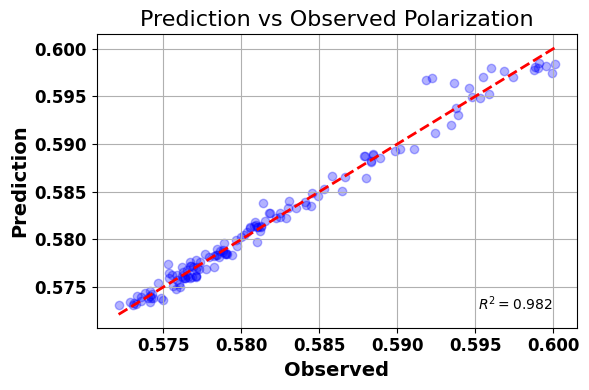

In [4]:
# ------------------------
# 0. Imports
# ------------------------
import os
import pickle
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import uncertainty_toolbox as uct
from scipy.stats import norm

# ------------------------
# Global Plot Style
# ------------------------
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# ------------------------
# 1. GP Model Class
# ------------------------
class GPModelTF:
    def __init__(self, kernel="laplace", lengthscale=1.0, coefficient=1.0, noise=1e-2):
        self.kernel = kernel
        self.lengthscale = lengthscale
        self.coefficient = coefficient
        self.noise = noise
        self.scaler_X = None
        self.scaler_y = None
        self.X_train_norm = None
        self.y_train_norm = None

    def _covariance(self, x1, x2, noise=None):
        x1 = tf.convert_to_tensor(x1, dtype=tf.float64)
        x2 = tf.convert_to_tensor(x2, dtype=tf.float64)
        diff = tf.expand_dims(x1, 1) - tf.expand_dims(x2, 0)

        if self.kernel == "eq":
            l2 = tf.reduce_sum((diff / self.lengthscale)**2, axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l2)
        elif self.kernel == "laplace":
            l1 = tf.reduce_sum(tf.abs(diff / self.lengthscale), axis=2)
            cov = self.coefficient**2 * tf.exp(-0.5 * l1)
        elif self.kernel == "cauchy":
            l2 = tf.reduce_sum((diff / self.lengthscale)**2, axis=2)
            cov = self.coefficient**2 / (1.0 + l2)
        else:
            raise ValueError("Unknown kernel type")

        if noise is not None:
            cov += noise**2 * tf.eye(tf.shape(cov)[0], dtype=tf.float64)
        return cov

    def fit(self, X_train, y_train):
        self.scaler_X = StandardScaler()
        self.X_train_norm = self.scaler_X.fit_transform(X_train)

        self.scaler_y = StandardScaler()
        self.y_train_norm = self.scaler_y.fit_transform(
            y_train.reshape(-1, 1)
        ).flatten()

    def predict(self, X_new):
        X_new_norm = self.scaler_X.transform(X_new)

        Kdd = self._covariance(self.X_train_norm, self.X_train_norm, noise=self.noise)
        Kpd = self._covariance(X_new_norm, self.X_train_norm)
        Kpp = self._covariance(X_new_norm, X_new_norm)

        alpha = tf.linalg.solve(Kdd, tf.expand_dims(self.y_train_norm, axis=1))
        mean_norm = tf.matmul(Kpd, alpha)[:, 0]
        cov = Kpp - tf.matmul(Kpd, tf.linalg.solve(Kdd, tf.transpose(Kpd)))
        var_norm = tf.linalg.diag_part(cov)

        mean_orig = self.scaler_y.inverse_transform(
            mean_norm.numpy().reshape(-1, 1)
        ).flatten()

        std_orig = (var_norm.numpy()**0.5) * self.scaler_y.scale_

        return mean_orig, std_orig


# ------------------------
# 2. Load and Prepare Data
# ------------------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv")
filtered_data = data[data['SampleID'] == '(P07)'].copy()

for col in ['start_time', 'end_time']:
    if col in filtered_data.columns:
        filtered_data[col] = pd.to_datetime(filtered_data[col], errors='coerce')

New_data = filtered_data[['uwave_freq',
                          'TGT:PT12:Target_Dose',
                          'scaler_calc1',
                          'polarization']]

X = New_data.iloc[:, 0:3].values
y = New_data.iloc[:, -1].values

# ------------------------
# 3. Train/Test Split
# ------------------------
dataset_size = X.shape[0]

tf.random.set_seed(42)
shuffled_indices = tf.random.shuffle(tf.range(dataset_size), seed=42)

train_split = int(0.70 * dataset_size)
val_split   = int(0.85 * dataset_size)

train_idx = shuffled_indices[:train_split]
val_idx   = shuffled_indices[train_split:val_split]
test_idx  = shuffled_indices[val_split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# ------------------------
# 4. Train GP
# ------------------------
gp_model = GPModelTF(
    kernel="laplace",
    lengthscale=1607.5127,
    coefficient=30.75,
    noise=0.11843
)

gp_model.fit(X_train, y_train)
mean_pred, std_pred = gp_model.predict(X_test)

filtered_test = filtered_data.iloc[test_idx].copy()
filtered_test['Polarization_Prediction'] = mean_pred
filtered_test['Polarization_Prediction_std'] = std_pred

filtered_test = filtered_test.sort_values('start_time').reset_index(drop=True)

# ------------------------
# 5. R²
# ------------------------
r2 = r2_score(
    filtered_test['polarization'],
    filtered_test['Polarization_Prediction']
)
print(f"R²: {r2:.3f}")

# ------------------------
# 6. Time Series Plot
# ------------------------
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(filtered_test['start_time'],
        filtered_test['polarization'],
        'r--', label='Observed')

ax.scatter(filtered_test['start_time'],
           filtered_test['Polarization_Prediction'],
           s=15, color='blue', label='Predicted')

ax.fill_between(
    filtered_test['start_time'],
    filtered_test['Polarization_Prediction'] - 2*filtered_test['Polarization_Prediction_std'],
    filtered_test['Polarization_Prediction'] + 2*filtered_test['Polarization_Prediction_std'],
    color='blue', alpha=0.2, label='Prediction Interval'
)

ax.set_xlabel("Time", fontweight='bold')
ax.set_ylabel("Polarization", fontweight='bold')
ax.set_title("Predictions with Uncertainty (Time Ordered)")
ax.set_ylim(0.55, 0.605)
ax.legend()
ax.grid(True)

# # Rotate x-axis tick labels 45 degrees
# for tick in ax.get_xticklabels():
#     tick.set_rotation(45)
#     tick.set_ha('right')     # align for better readability
#     tick.set_fontweight("bold")

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

ax.tick_params(axis='x', rotation=30)

ax.text(0.02, 0.05, f"$R^2 = {r2:.3f}$",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.6))

plt.tight_layout()
plt.show()


# ------------------------
# 9. Prediction vs Observed
# ------------------------
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(filtered_test['polarization'],
           filtered_test['Polarization_Prediction'],
           alpha=0.3, color='blue')

min_val = filtered_test['polarization'].min()
max_val = filtered_test['polarization'].max()

ax.plot([min_val, max_val],
        [min_val, max_val],
        'r--', lw=2)

ax.set_xlabel("Observed", fontweight='bold')
ax.set_ylabel("Prediction", fontweight='bold')
ax.set_title("Prediction vs Observed Polarization")
ax.grid(True)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

ax.text(0.95, 0.05,
        f"$R^2 = {r2:.3f}$",
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='bottom')

plt.tight_layout()
plt.show()


# MLP model development

In [5]:

# 0. Imports
# ------------------------
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Normalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct


# ------------------------
# EXACT Plot Style You Requested
# ------------------------
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})


# ------------------------
# 1. Load and prepare data
# ------------------------
polarized_proton = pd.read_csv("polarized_proton_data_with_current.csv")

data = polarized_proton[
    polarized_proton['SampleID'].astype(str).str.strip() == '(P07)'
].reset_index(drop=True)

if 'start_time' in data.columns:
    data['start_time'] = pd.to_datetime(data['start_time'], errors='coerce')
if 'end_time' in data.columns:
    data['end_time'] = pd.to_datetime(data['end_time'], errors='coerce')

feature_cols = ['uwave_freq', 'TGT:PT12:Target_Dose', 'scaler_calc1']
target_col = 'polarization'

X = tf.convert_to_tensor(data[feature_cols].values, dtype=tf.float32)
y = tf.abs(tf.convert_to_tensor(data[target_col].values, dtype=tf.float32))


# ------------------------
# 2. Train / Val / Test split
# ------------------------
dataset_size = X.shape[0]
indices = tf.range(dataset_size)

tf.random.set_seed(42)
shuffled_indices = tf.random.shuffle(indices, seed=42)

train_split = int(0.70 * dataset_size)
val_split   = int(0.85 * dataset_size)

train_indices = shuffled_indices[:train_split]
val_indices   = shuffled_indices[train_split:val_split]
test_indices  = shuffled_indices[val_split:]

X_train = tf.gather(X, train_indices)
y_train = tf.gather(y, train_indices)

X_val = tf.gather(X, val_indices)
y_val = tf.gather(y, val_indices)

X_test = tf.gather(X, test_indices)
y_test = tf.gather(y, test_indices)

train_idx_np = train_indices.numpy()
test_idx_np  = test_indices.numpy()


# ------------------------
# 3. Feature normalization
# ------------------------
normalizer = Normalization(axis=-1)
normalizer.adapt(X_train)

X_train_scaled = normalizer(X_train)
X_test_scaled  = normalizer(X_test)

y_mean = tf.reduce_mean(y_train)
y_std  = tf.math.reduce_std(y_train)
y_train_scaled = (y_train - y_mean) / y_std


# ------------------------
# 4. NLL Gaussian loss
# ------------------------
def nll_gaussian(y_true, y_pred):
    mean = y_pred[:, 0]
    log_var = tf.clip_by_value(y_pred[:, 1], -10.0, 10.0)
    precision = tf.exp(-log_var)
    return tf.reduce_mean(0.5 * (log_var + tf.square(y_true - mean) * precision))


# ------------------------
# 5. Build model
# ------------------------
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation='relu'),
    Dropout(0.25),
    Dense(512, activation='relu'),
    Dropout(0.25),
    Dense(2, bias_initializer=tf.keras.initializers.Constant([0.0, -1.0]))
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss=nll_gaussian)


# ------------------------
# 6. Train
# ------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=1000,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


# ------------------------
# 7. Predictions
# ------------------------
preds_scaled = model(X_test_scaled)
pred_mean_scaled = preds_scaled[:, 0]
pred_log_var = tf.clip_by_value(preds_scaled[:, 1], -10.0, 10.0)
pred_std_scaled = tf.sqrt(tf.exp(pred_log_var))

pred_mean = pred_mean_scaled * y_std + y_mean
pred_std  = pred_std_scaled * y_std


# ------------------------
# 8. Prepare DataFrame
# ------------------------
X_test_final = data.iloc[test_idx_np][
    ['start_time','end_time','RunNumber',
     'uwave_freq','TGT:PT12:Target_Dose','scaler_calc1']
].copy()

X_test_final['Polarization_GT'] = y_test.numpy()
X_test_final['Polarization_Prediction'] = pred_mean.numpy()
X_test_final['Polarization_Prediction_std'] = pred_std.numpy()

if 'start_time' in X_test_final.columns:
    X_test_final = X_test_final.sort_values('start_time').reset_index(drop=True)


# ------------------------
# 9. R²
# ------------------------
r2 = r2_score(
    X_test_final['Polarization_GT'],
    X_test_final['Polarization_Prediction']
)




Epoch 1/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5186 - val_loss: 0.3261
Epoch 2/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0825 - val_loss: 0.0570
Epoch 3/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.0803 - val_loss: -0.0722
Epoch 4/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.1785 - val_loss: -0.1920
Epoch 5/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.2995 - val_loss: -0.3141
Epoch 6/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.4055 - val_loss: -0.4389
Epoch 7/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.4829 - val_loss: -0.5486
Epoch 8/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.5583 - val_loss: -0.6153
Epoch 9/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.6640 - val_loss: -0.7097
Epoch 10/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.6741 - val_loss: -0.7549
Epoch 11/1000
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: -0.7282 - val_loss: -0.7941
Epoch 12/1000
17/17 ━━━━━━━━━━━━━━

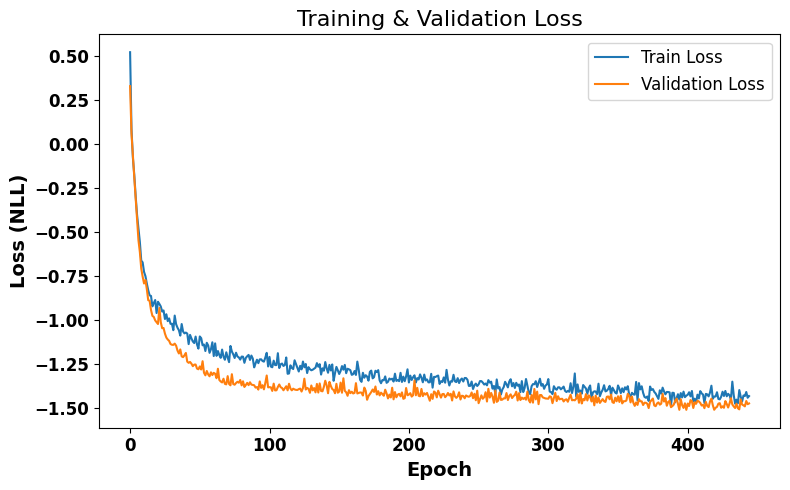

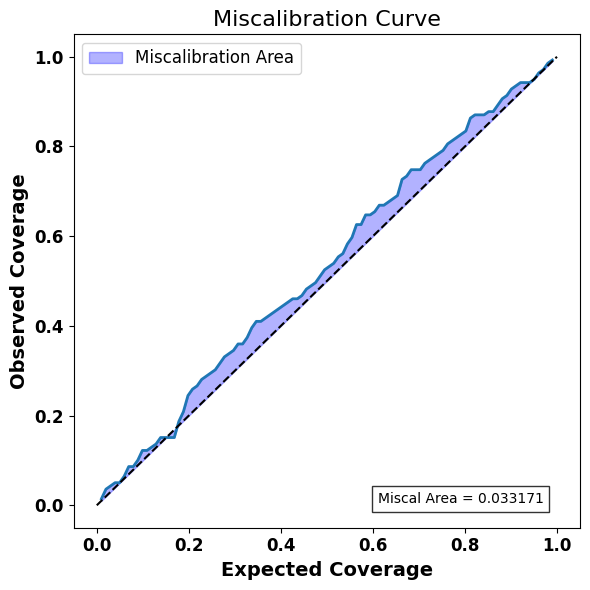

R²: 0.9642186164855957
Miscalibration area: 0.0331713538260301


In [6]:


# ------------------------
# 10. Training Loss Plot
# ------------------------
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch',fontweight='bold')
ax.set_ylabel('Loss (NLL)',fontweight='bold')
ax.set_title('Training & Validation Loss')
ax.legend()

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

plt.tight_layout()
plt.show()


# ------------------------
# 11. Miscalibration Curve
# ------------------------
def draw_miscalibration_curve(pred_mean, pred_std, y_true, n_bins=100):

    p_exp = np.linspace(0.01, 0.99, n_bins)
    p_obs = []

    for p in p_exp:
        z = norm.ppf((1 + p) / 2.0)
        inside = np.abs(y_true - pred_mean) <= z * pred_std
        p_obs.append(np.mean(inside))

    p_obs = np.array(p_obs)

    miscal = np.mean(np.abs(p_obs - p_exp))  # unchanged

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(p_exp, p_obs, linewidth=2)
    ax.plot([0, 1], [0, 1], "k--")

    ax.fill_between(
        p_exp,
        p_obs,
        p_exp,
        color="blue",
        alpha=0.3,
        label="Miscalibration Area"
    )

    ax.set_xlabel("Expected Coverage",fontweight='bold')
    ax.set_ylabel("Observed Coverage",fontweight='bold')
    ax.set_title("Miscalibration Curve")
    ax.legend()

    ax.text(
        0.60, 0.05,
        f"Miscal Area = {miscal:.6f}",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    plt.tight_layout()
    plt.show()

    return miscal


miscal = draw_miscalibration_curve(
    X_test_final['Polarization_Prediction'].values,
    X_test_final['Polarization_Prediction_std'].values,
    X_test_final['Polarization_GT'].values
)

print("R²:", r2)
print("Miscalibration area:", miscal)


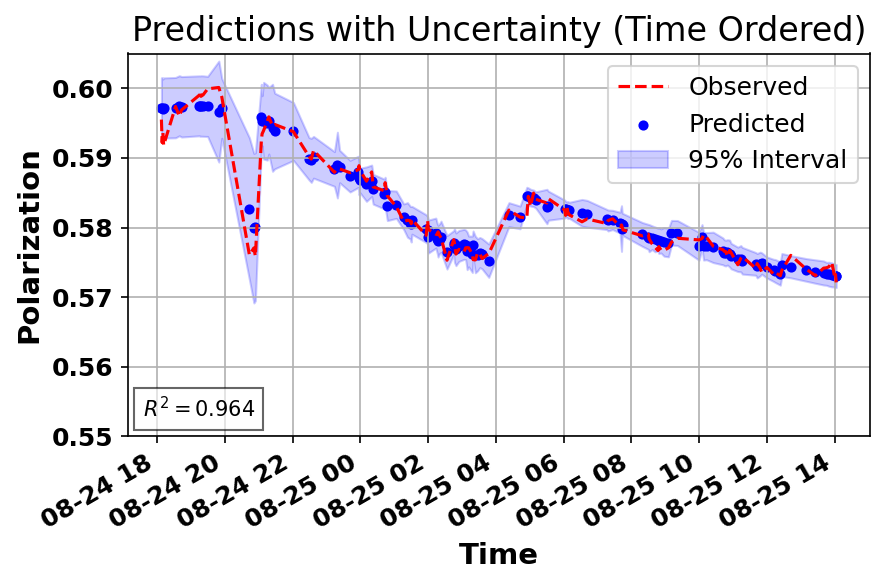

In [7]:
fig, ax = plt.subplots(figsize=(6,4), dpi=150)

ax.plot(X_test_final['start_time'],
        X_test_final['Polarization_GT'],
        'r--', label='Observed')

ax.scatter(X_test_final['start_time'],
           X_test_final['Polarization_Prediction'],
           s=15, color='blue', label='Predicted')

ax.fill_between(
    X_test_final['start_time'],
    X_test_final['Polarization_Prediction'] - 2 * X_test_final['Polarization_Prediction_std'],
    X_test_final['Polarization_Prediction'] + 2 * X_test_final['Polarization_Prediction_std'],
    color='blue', alpha=0.2, label='95% Interval'
)

ax.set_xlabel("Time",fontweight='bold')
ax.set_ylabel("Polarization",fontweight='bold')
ax.set_title("Predictions with Uncertainty (Time Ordered)")
ax.legend()
ax.grid(True)
ax.set_ylim(0.55, 0.605)

ax.text(0.02, 0.05, f"$R^2 = {r2:.3f}$",
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.6))

# Rotate x-axis tick labels 45 degrees
for tick in ax.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha('right')     # align for better readability
    tick.set_fontweight("bold")

# Keep y-axis bold
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

plt.tight_layout()
plt.show()


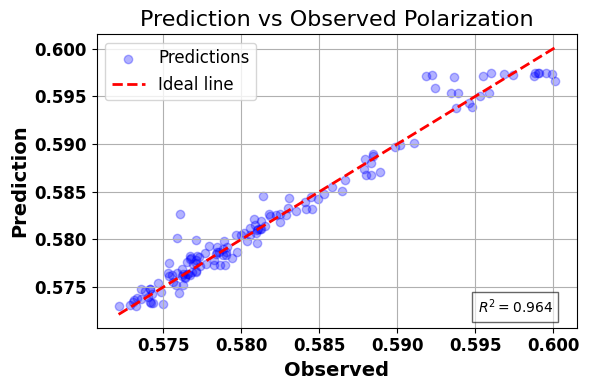

In [8]:
# ------------------------
# 9. R²
# ------------------------
r2 = r2_score(
    X_test_final['Polarization_GT'],
    X_test_final['Polarization_Prediction']
)
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(
    X_test_final['Polarization_GT'],
    X_test_final['Polarization_Prediction'],
    alpha=0.3, color='blue', label='Predictions'
)

min_val = X_test_final['Polarization_GT'].min()
max_val = X_test_final['Polarization_GT'].max()

ax.plot([min_val, max_val],
        [min_val, max_val],
        'r--', lw=2, label="Ideal line")

ax.set_xlabel("Observed",fontweight='bold')
ax.set_ylabel("Prediction",fontweight='bold')
ax.set_title("Prediction vs Observed Polarization")
ax.legend()
ax.grid(True)

ax.text(0.95, 0.05, f"$R^2 = {r2:.3f}$",
        transform=ax.transAxes,
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.6))

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

plt.tight_layout()
plt.show()


# OOD analysis of GP and MLP

139


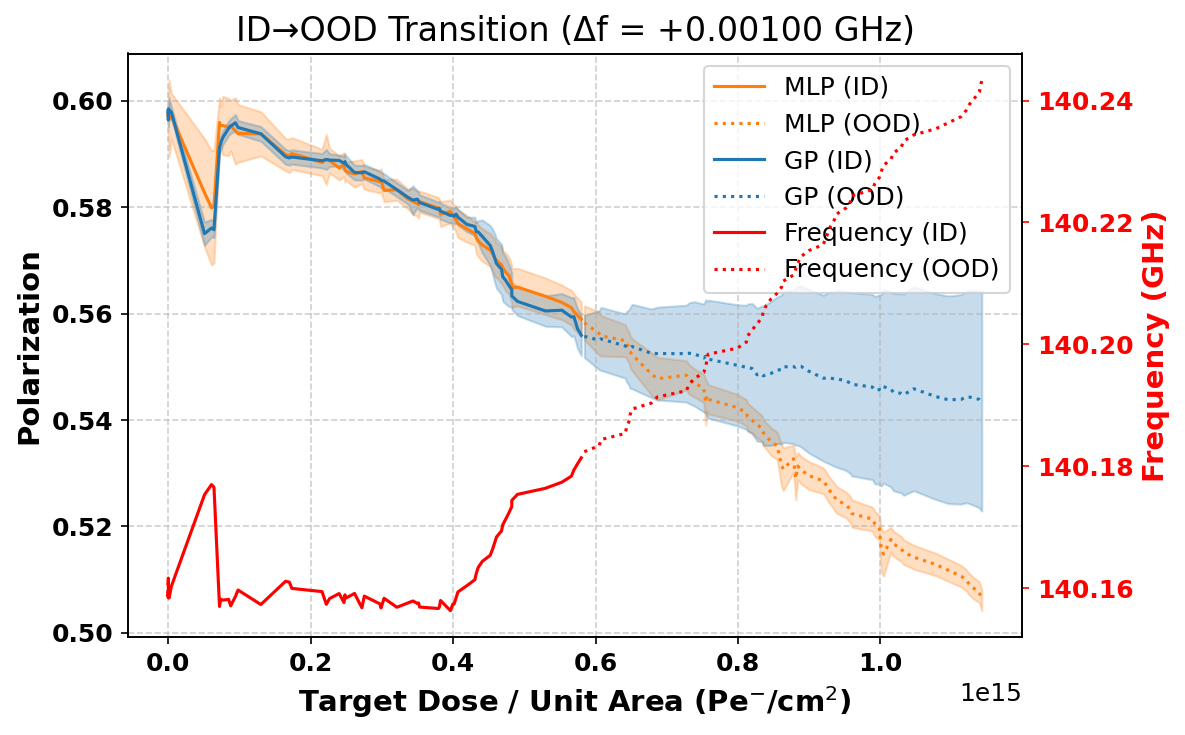

139


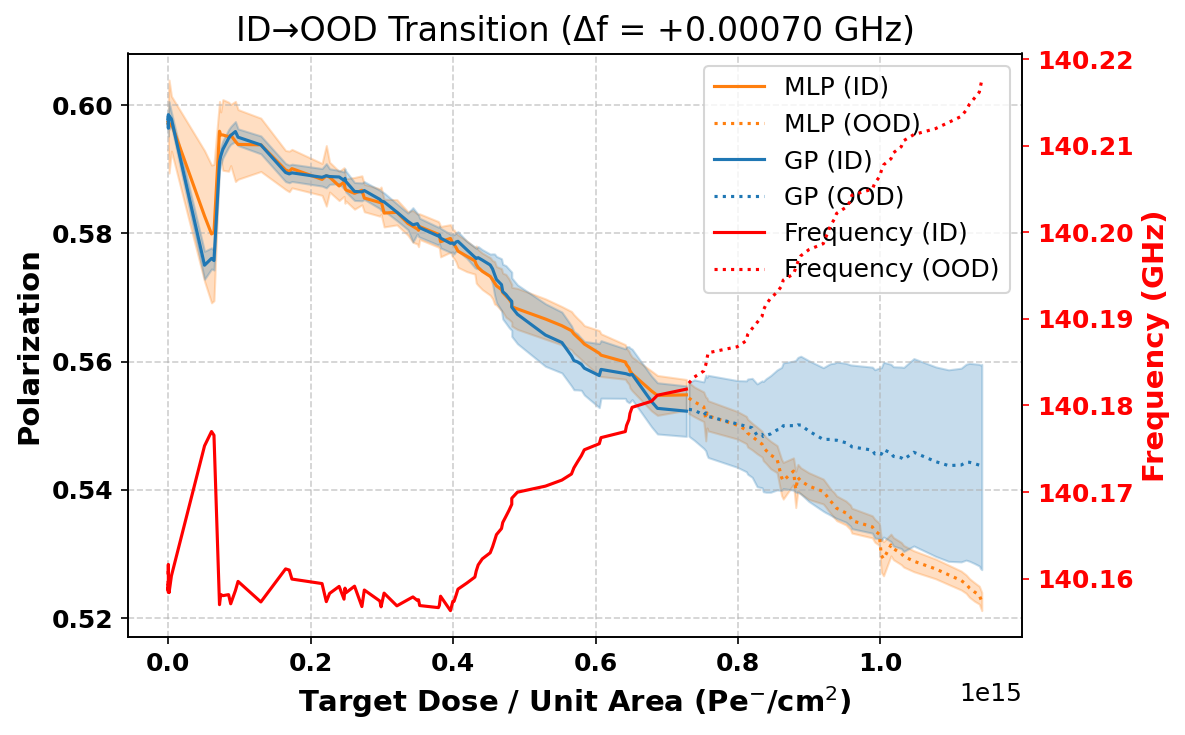

139


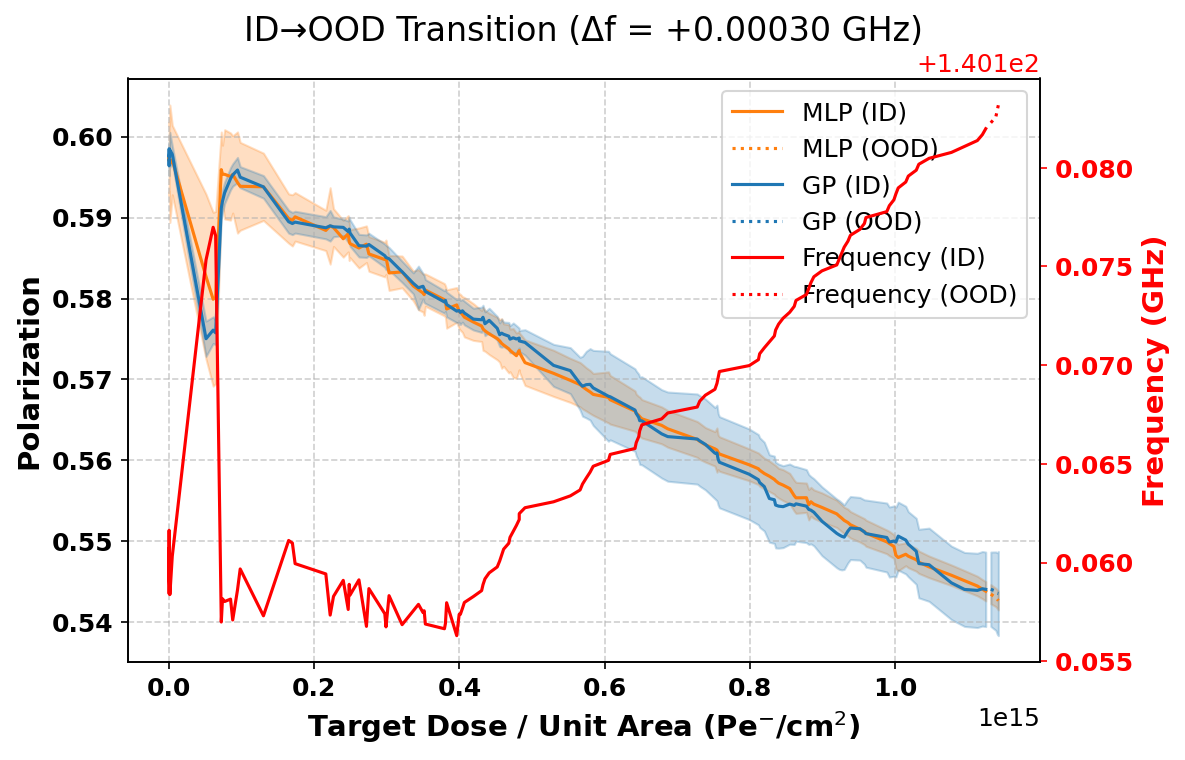

139


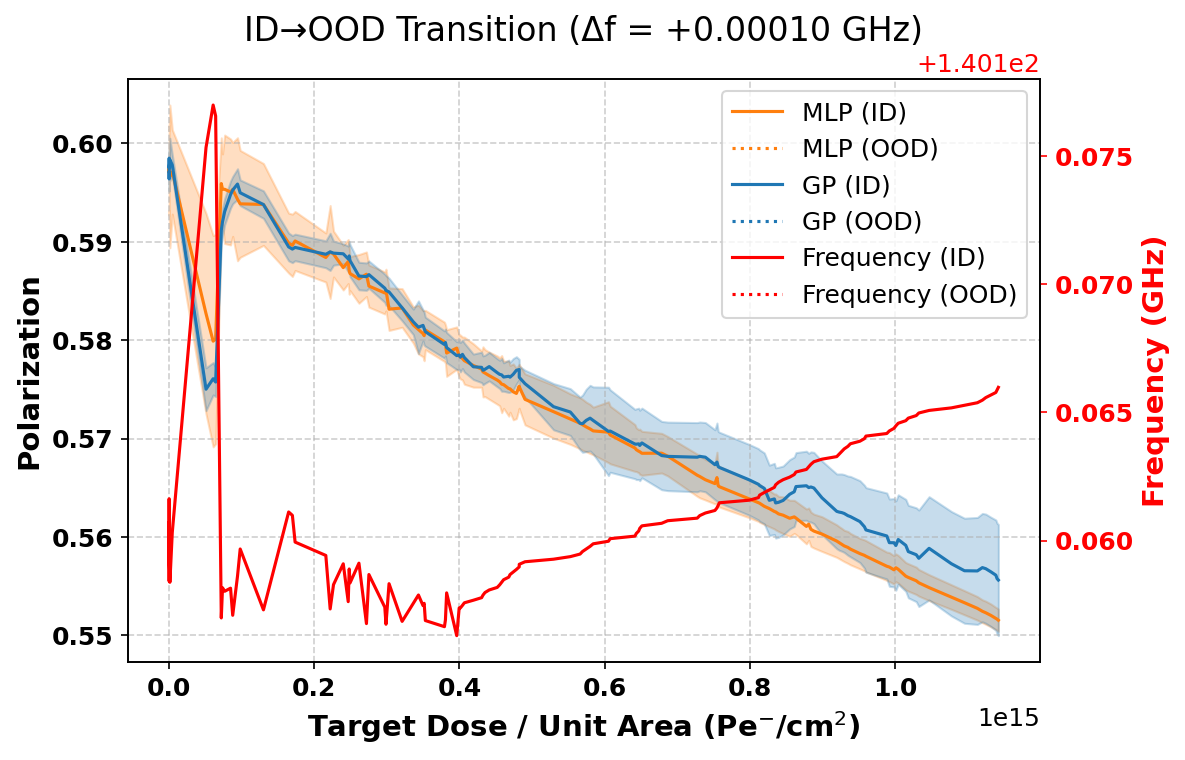

139


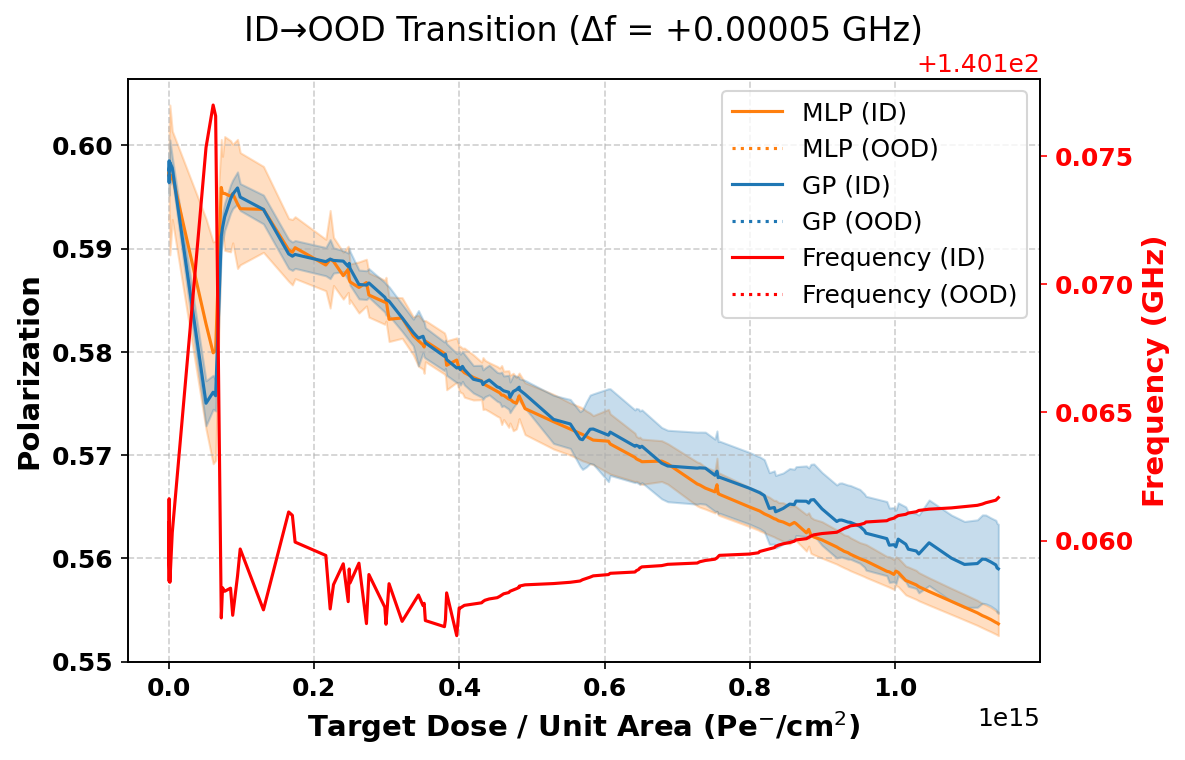

139


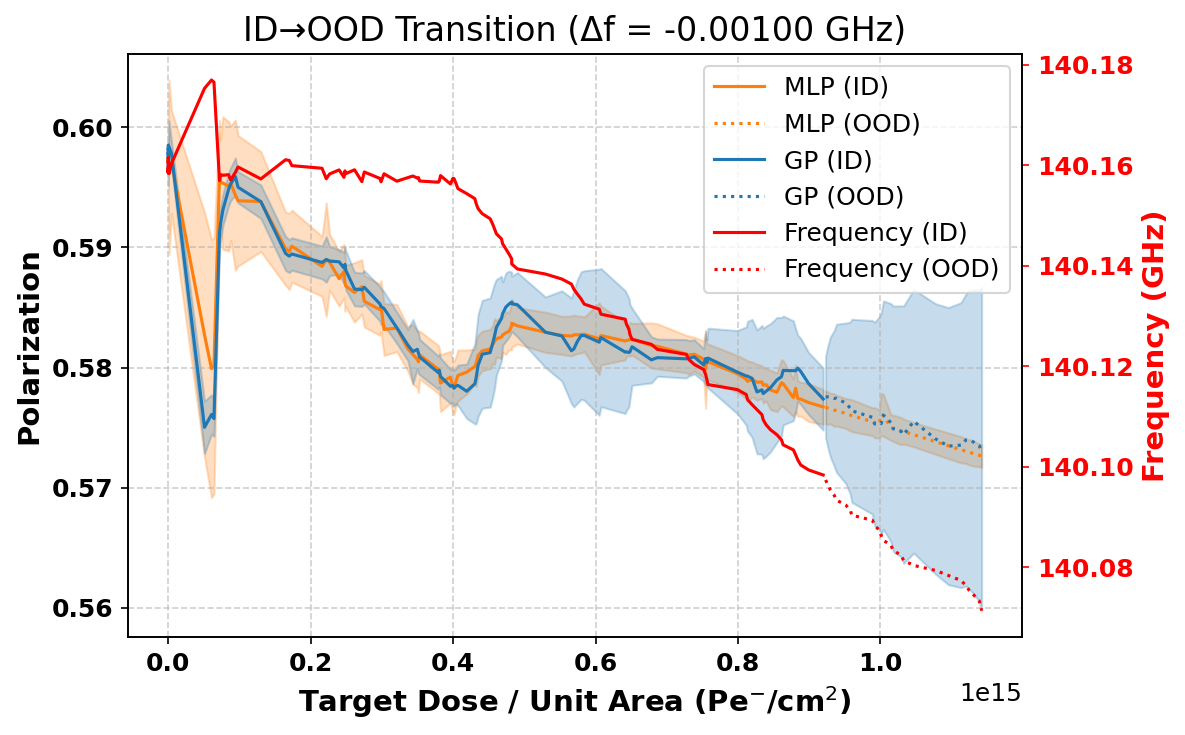

139


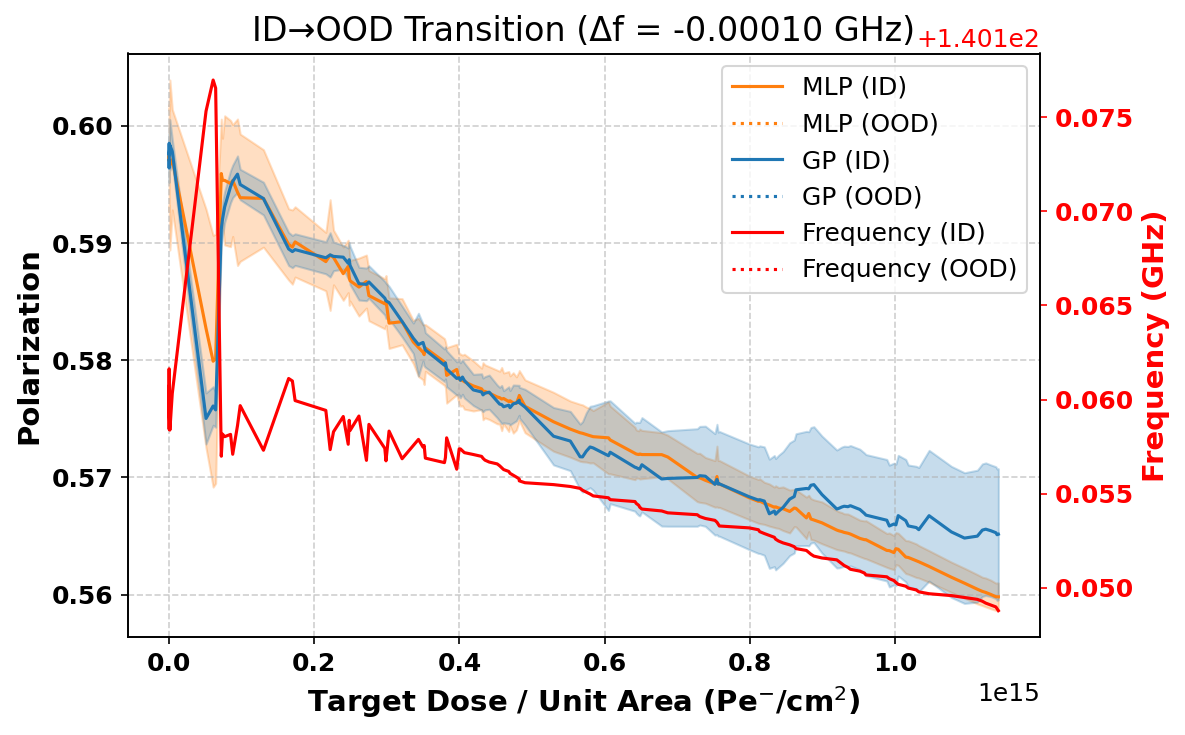

139


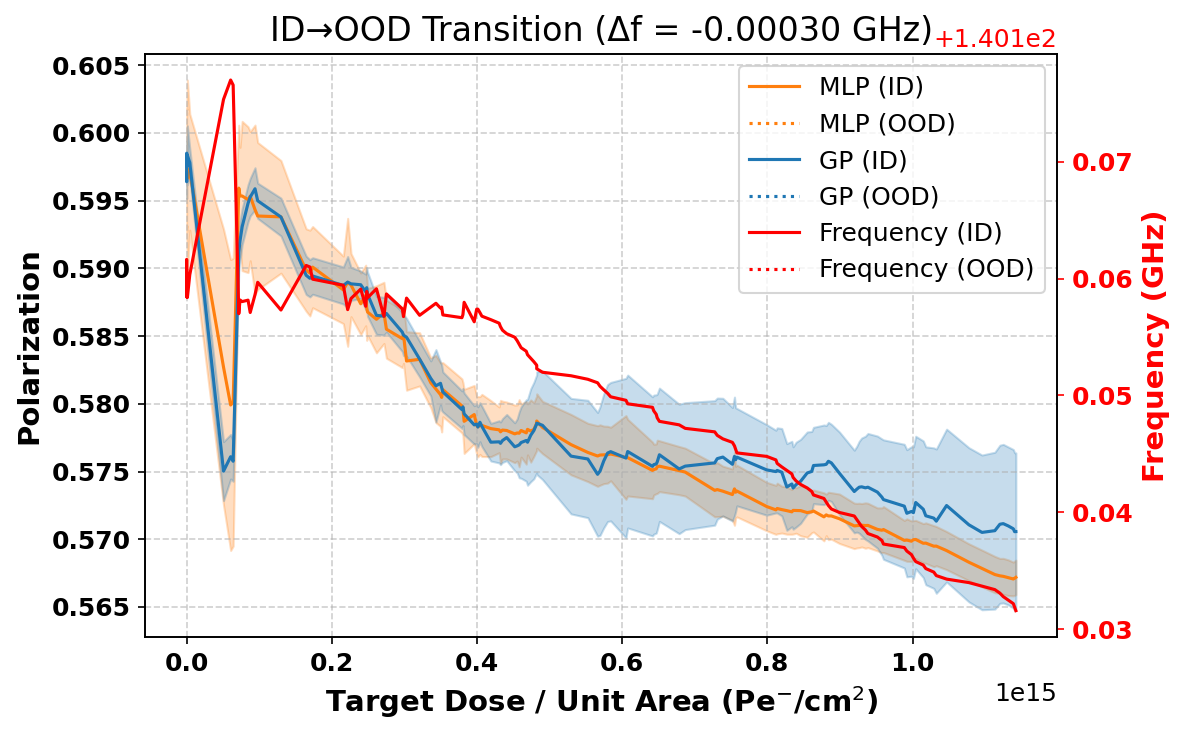

139


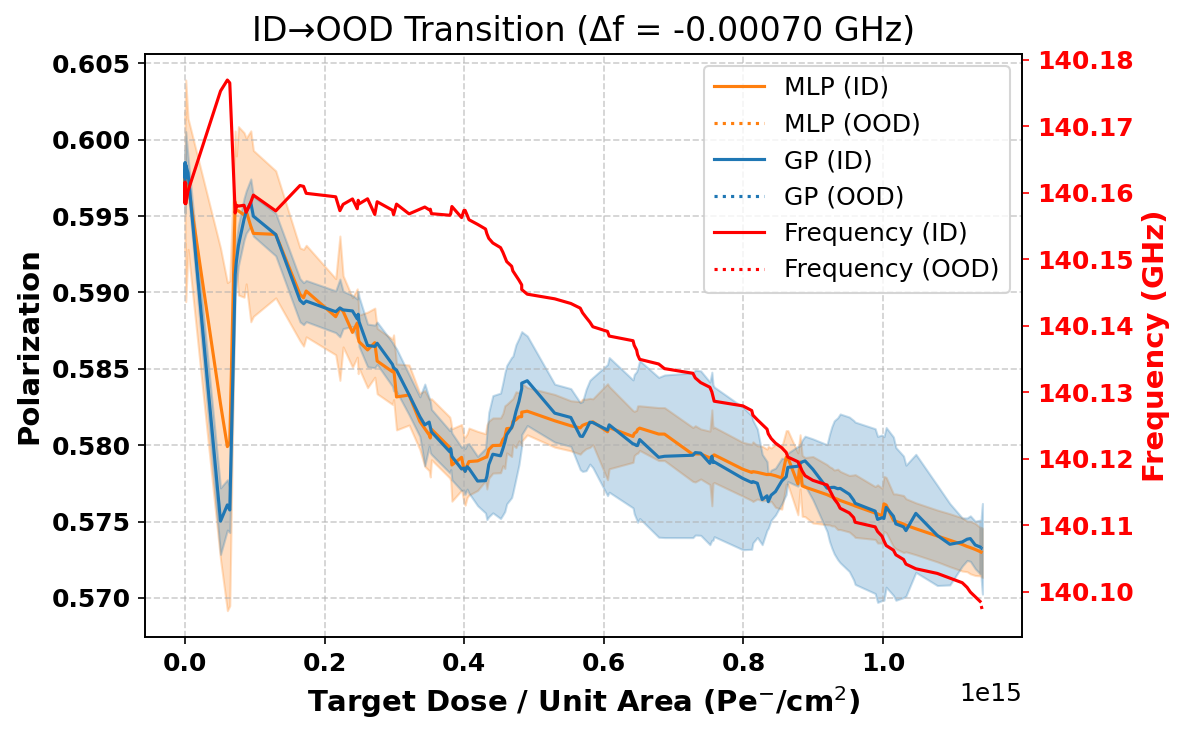

139


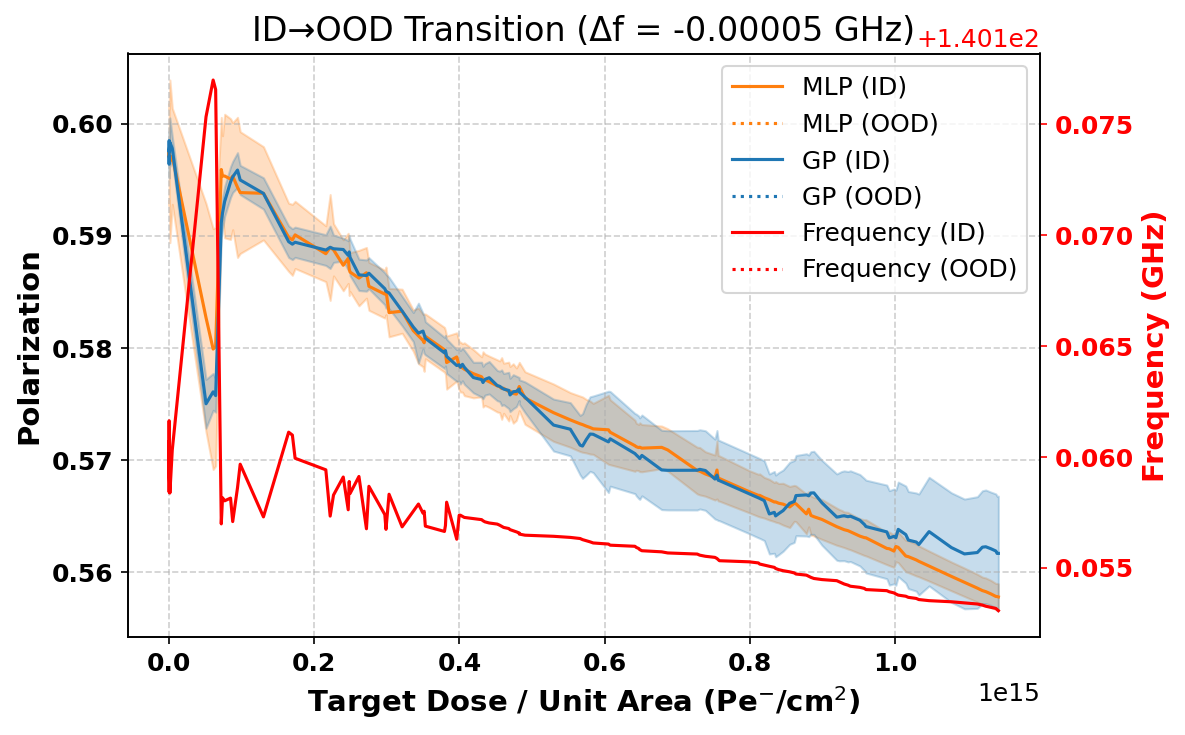

In [24]:

# filtered_test = pd.read_csv('/Users/monibor/Desktop/AIOP Target Optimization/untitled folder/GP/increment_decrement_results/increment_decrement_full_results.csv')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# --- Increment/decrement list ---
increments = [0.001, 0.0007, 0.0003, 0.0001, 0.00005,
              -0.001, -0.0001, -0.0003, -0.0007, -0.00005]

# Original frequency
original_freq = filtered_test['uwave_freq'].copy()

# Upper and lower threshold frequencies
upper_threshold = 140.1822  # frequency above this → OOD
lower_threshold = 140.0979  # frequency below this → OOD

for inc in increments:
    temp = filtered_test.copy()
    temp['uwave_freq_OOD'] = original_freq.copy()

    # Dose threshold masks
    dose_threshold = 0.4e15
    mask_id = temp['TGT:PT12:Target_Dose'] <= dose_threshold
    mask_ood = temp['TGT:PT12:Target_Dose'] > dose_threshold
    num_ood = mask_ood.sum()

    # Increment/decrement OOD frequency
    if num_ood > 0:
        last_id_freq = original_freq[mask_id].iloc[-1]
        temp.loc[mask_ood, 'uwave_freq_OOD'] = last_id_freq + np.arange(num_ood) * inc

    # --- GP predictions ---
    Data_OOD = temp[['uwave_freq_OOD', 'TGT:PT12:Target_Dose','scaler_calc1']].values
    mean_pred_OOD, std_pred_OOD = gp_model.predict(Data_OOD)
    print(len(mean_pred_OOD))
    temp['mean_OOD'] = mean_pred_OOD
    temp['std_OOD'] = std_pred_OOD

    # --- MLP predictions ---
    temp["MLP_pred"] = X_test_final["Polarization_Prediction"]
    temp["MLP_std"] = X_test_final["Polarization_Prediction_std"]

    test_data_MLP_OOD = temp[['uwave_freq_OOD', 'TGT:PT12:Target_Dose', 'scaler_calc1']].values
    X_test_scaled_OOD = normalizer(test_data_MLP_OOD)
    preds_scaled_OOD = model(X_test_scaled_OOD)
    pred_mean_OOD = preds_scaled_OOD[:,0] * y_std + y_mean
    pred_std_OOD = tf.sqrt(tf.clip_by_value(tf.exp(preds_scaled_OOD[:,1]), 1e-10, 1e10)) * y_std
    temp["MLP_pred_OOD"] = pred_mean_OOD
    temp["MLP_std_OOD"] = pred_std_OOD

    # --- Extract data ---
    dose = temp['TGT:PT12:Target_Dose'].values
    freq = temp['uwave_freq_OOD'].values
    mlp = temp['MLP_pred_OOD'].values
    mlp_std = temp['MLP_std_OOD'].values
    gp = temp['mean_OOD'].values
    gp_std = temp['std_OOD'].values

    # --- ID / OOD masks based on frequency thresholds ---
    id_mask = (freq >= lower_threshold) & (freq <= upper_threshold)
    ood_mask = (freq > upper_threshold) | (freq < lower_threshold)

    fig, ax1 = plt.subplots(figsize=(8,5), dpi=150)

    # --- MLP ---
    ax1.plot(dose[id_mask], mlp[id_mask], color='tab:orange', linewidth=1.5, label='MLP (ID)')
    ax1.fill_between(dose[id_mask], mlp[id_mask]-2*mlp_std[id_mask], mlp[id_mask]+2*mlp_std[id_mask],
                     color='tab:orange', alpha=0.25)
    ax1.plot(dose[ood_mask], mlp[ood_mask], color='tab:orange', linestyle=':', linewidth=1.5, label='MLP (OOD)')
    ax1.fill_between(dose[ood_mask], mlp[ood_mask]-2*mlp_std[ood_mask], mlp[ood_mask]+2*mlp_std[ood_mask],
                     color='tab:orange', alpha=0.25)

    # --- GP ---
    ax1.plot(dose[id_mask], gp[id_mask], color='tab:blue', linewidth=1.5, label='GP (ID)')
    ax1.fill_between(dose[id_mask], gp[id_mask]-2*gp_std[id_mask], gp[id_mask]+2*gp_std[id_mask],
                     color='tab:blue', alpha=0.25)
    ax1.plot(dose[ood_mask], gp[ood_mask], color='tab:blue', linestyle=':', linewidth=1.5, label='GP (OOD)')
    ax1.fill_between(dose[ood_mask], gp[ood_mask]-2*gp_std[ood_mask], gp[ood_mask]+2*gp_std[ood_mask],
                     color='tab:blue', alpha=0.25)

    ax1.set_xlabel("Target Dose / Unit Area (Pe$^{-}$/cm$^{2}$)", fontweight='bold')
    # plt.xlabel(r"Target Dose / Area (Pe$^{-}$/cm$^{2}$)", fontweight='bold')
    ax1.set_ylabel("Polarization", fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Frequency line ---
    ax2 = ax1.twinx()
    ax2.plot(dose[id_mask], freq[id_mask], color='red', linewidth=1.5, label='Frequency (ID)')
    ax2.plot(dose[ood_mask], freq[ood_mask], color='red', linestyle=':', linewidth=1.5, label='Frequency (OOD)')
    ax2.set_ylabel("Frequency (GHz)", fontweight='bold', color='red')
    ax2.tick_params(axis='y', colors='red')

    # --- Combined legend ---
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.title(f"ID→OOD Transition (Δf = {inc:+.5f} GHz)")

    # ---- EXACT formatting you requested ----
    for tick in ax1.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax1.get_yticklabels():
        tick.set_fontweight("bold")

    for tick in ax2.get_yticklabels():
        tick.set_fontweight("bold")

    plt.tight_layout()
    plt.show()

    # # --- Combined legend ---
    # lines1, labels1 = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=6)

    # plt.title(f"ID→OOD Transition (Δf = {inc:+.5f} GHz)", fontsize=11)
    # plt.tight_layout()
    # plt.show()


In [56]:
filtered_test

,RunNumber,SampleID,scaler_calc1,polarization,uwave_freq,TGT:PT12:Target_Dose,start_time,end_time
6062,16768.0,(P07),3.782388,0.593768,140.157303,1.299512e+14,2022-08-24 22:01:29.833586,2022-08-24 22:02:49.061142+00:00
6159,NaN,(P07),3.707791,0.586659,140.159123,2.614964e+14,2022-08-25 00:10:53.660562,2022-08-25 00:12:12.873761+00:00
6187,16769.0,(P07),0.003973,0.584563,140.158323,3.029773e+14,2022-08-25 00:47:51.768205,2022-08-25 00:49:10.985449+00:00
6683,16772.0,(P07),3.875303,0.574834,140.123024,9.921771e+14,2022-08-25 11:42:47.322728,2022-08-25 11:44:06.537897+00:00
6283,16770.0,(P07),3.810638,0.576874,140.156383,4.409360e+14,2022-08-25 02:54:37.072047,2022-08-25 02:55:56.284032+00:00
...,...,...,...,...,...,...,...,...
6254,NaN,(P07),3.836901,0.578989,140.157378,3.995853e+14,2022-08-25 02:16:19.652213,2022-08-25 02:17:38.872253+00:00
6774,16772.0,(P07),4.030015,0.574226,140.099913,1.120370e+15,2022-08-25 13:45:34.861558,2022-08-25 13:46:54.086827+00:00
6267,NaN,(P07),3.854116,0.575305,140.159467,4.191162e+14,2022-08-25 02:33:29.546037,2022-08-25 02:34:48.755966+00:00
6537,16771.0,(P07),3.926286,0.579047,140.119270,8.118198e+14,2022-08-25 08:30:00.914935,2022-08-25 08:31:20.129470+00:00


# GPA Generalized model

In [39]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from datetime import datetime
import os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct

# ---------------- Load data ----------------
data = pd.read_csv("/Users/monibor/Desktop/polarized_proton_data_with_current.csv") 

# Include multiple SampleIDs
filtered_data = data[data["SampleID"].isin(["(P07)", "(P14)", "(P11)"])].reset_index(drop=True)

feature_cols = ["scaler_calc1", "uwave_freq", "TGT:PT12:Target_Dose"]
X = filtered_data[feature_cols].values
y = filtered_data["polarization"].values.reshape(-1, 1)

# ---------------- Train/Validation/Test Split ----------------
# Balanced representation of the target variable (y) distribution across train, validation, and test splits.
y_quantiles = pd.qcut(y.ravel(), q=10, labels=False)

X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, filtered_data.index.values, test_size=0.1, random_state=42, stratify=y_quantiles
)

y_trainval_quantiles = pd.qcut(y_trainval.ravel(), q=10, labels=False)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_trainval, y_trainval, idx_trainval, test_size=0.1111, random_state=42, stratify=y_trainval_quantiles
)  

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

# ---------------- Standardize (fit on training only) ----------------
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_val_scaled = scaler_y.transform(y_val).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

# ---------------- GPA-RFF Model ----------------
class GPA_RFF:
    def __init__(self, X, y, kernel="RBF", D=500, seed=42):
        self.X = X.astype(np.float64)
        self.y = y.astype(np.float64)
        self.kernel = kernel.upper()
        self.D = D
        np.random.seed(seed)

        self.b = 2 * np.pi * np.random.rand(D)
        self.W = None
        self.beta = None
        self.opt_params = None

        self.log_lengthscale = np.log(1.0)
        self.log_coeff = np.log(1.0)
        self.log_noise = np.log(1e-2)

    def _sample_W(self, lengthscale):
        d = self.X.shape[1]
        if self.kernel in ["RBF", "EQ"]:
            return np.random.normal(0, 1.0 / lengthscale, (d, self.D))
        elif self.kernel == "LAPLACE":
            return np.random.standard_cauchy((d, self.D)) / lengthscale
        elif self.kernel == "CAUCHY":
            return np.random.laplace(0, 1.0 / lengthscale, (d, self.D))
        else:
            raise ValueError(f"Unknown kernel: {self.kernel}")

    def _phi(self, X, W, coeff):
        return np.sqrt(2/self.D) * np.cos(X @ W + self.b) * coeff # RFF transformation

    def neg_log_likelihood(self, params):
        lengthscale, coeff, noise = np.exp(params)

        # Clamp
        lengthscale = np.clip(lengthscale, 1e-2, 1e5)
        coeff      = np.clip(coeff, 1e-6, 1e5)
        noise      = np.clip(noise, 1e-4, 10.0)

        # Sample random features
        if self.W is None:
            self.W = self._sample_W(lengthscale)

        Phi = self._phi(self.X, self.W, coeff)  # n × D
        n, D = Phi.shape

        # Compute A = Phi^T Phi + noise^2 I
        A = Phi.T @ Phi + (noise**2) * np.eye(D)

        # Cholesky solve for log|A|
        try:
            L = np.linalg.cholesky(A)
        except:
            return 1e10

        # Compute alpha = A^{-1} Phi^T y  (in dual form)
        alpha = np.linalg.solve(A, Phi.T @ self.y)

        # Compute GP terms using Woodbury identity
        # y^T K^{-1} y = 1/noise^2 * ( y^T y - y^T Phi alpha )
        yt_y = np.dot(self.y, self.y)
        yt_Phi_alpha = np.dot(self.y, Phi @ alpha)

        quad_term = (yt_y - yt_Phi_alpha) / (noise**2)

        # log|K| = n*log(noise^2) + log|A|
        logdet_K = n * np.log(noise**2) + 2.0 * np.sum(np.log(np.diag(L)))

        # Final GP marginal likelihood
        nll = 0.5 * quad_term + 0.5 * logdet_K + 0.5 * n * np.log(2*np.pi)
        return nll
    
    def fit(self, method="L-BFGS-B"):
        init = [self.log_lengthscale, self.log_coeff, self.log_noise]
        # Initial boundary
        bounds = [
            (np.log(1e-2), np.log(1e5)),
            (np.log(1e-6), np.log(1e5)),
            (np.log(1e-3), np.log(10.0)),
        ]
        res = minimize(self.neg_log_likelihood, init, method=method, bounds=bounds) # Scipy minimizer
        self.opt_params = np.exp(res.x)

        lengthscale, coeff, noise = self.opt_params
        self.W = self._sample_W(lengthscale)
        phi = self._phi(self.X, self.W, coeff)
        K_ridge = phi.T @ phi + (noise**2) * np.eye(self.D)
        self.beta = np.linalg.solve(K_ridge, phi.T @ self.y)
        return res

    def predict(self, X_new, return_std=True):
        lengthscale, coeff, noise = self.opt_params
        phi_new = self._phi(X_new, self.W, coeff)
        y_pred = phi_new @ self.beta # Mean
        y_pred = y_pred.ravel() 

        # Training feature matrix
        phi_train = self._phi(self.X, self.W, coeff)
        
        # Sigma_t = Φ^T Φ + σ^2 I
        Sigma_t = phi_train.T @ phi_train + (noise**2) * np.eye(self.D)
        
        # Solve Sigma_t * v = phi_new^T
        v = np.linalg.solve(Sigma_t, phi_new.T)
        
        # Predictive variance: ˆσ^2_t(x) = σ^2 φ(x)^T Σ_t^{-1} φ(x)
        y_var = noise**2 * np.sum(phi_new * v.T, axis=1)
        y_std = np.sqrt(np.maximum(y_var, 1e-12))
        return y_pred, y_std.ravel()



# ---------------- Run experiments ----------------
# os.makedirs("Results_GPA_D2048", exist_ok=True)
summary_path = "/Users/monibor/Desktop/AIOP Target Optimization/Paper/Figures/Updated_figures_feb17/GPA/gpa_rff_summary.csv"

# Initialize metrics summary file
summary_cols = ["Kernel", "Optimizer", "Dataset", "MSE", "R2", "NLL", "Miscal_Area"]
if not os.path.exists(summary_path):
    pd.DataFrame(columns=summary_cols).to_csv(summary_path, index=False)

kernels = ["LAPLACE"]
methods = ["Nelder-Mead", "L-BFGS-B"]

for kernel in kernels:
    print("="*70)
    print(f"Kernel: {kernel}")
    for method in methods:
        print(f"\nOptimizer: {method}")

        gp = GPA_RFF(X_train_scaled, y_train_scaled, kernel=kernel, D=4096)
        try:
            res = gp.fit(method=method)
            print(f"Optimized params [lengthscale, coeff, noise]: {gp.opt_params}")

            coverage_levels = np.linspace(0, 1, 100)
            # predict for all data separately (train, val and test)

            datasets = [
                ("train", X_train_scaled, y_train, idx_train),
                ("val", X_val_scaled, y_val, idx_val),
                ("test", X_test_scaled, y_test, idx_test)
            ]

            for name, Xs, Ys, idxs in datasets:
                # Predict
                y_pred, y_std = gp.predict(Xs)
                y_orig = Ys.ravel()
                # Back to original labels
                y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1,1)).ravel()
                y_std_orig = y_std * scaler_y.scale_[0]

                # Reconstruct original features 
                df_features = pd.DataFrame(
                    scaler_X.inverse_transform(Xs), 
                    columns=feature_cols
                )
                df_features["start_time"] = filtered_data.loc[idxs, "start_time"].values
                df_features["end_time"] = filtered_data.loc[idxs, "end_time"].values

                df = pd.DataFrame({
                    "SampleID": filtered_data.loc[idxs, "SampleID"].values,
                    **df_features,
                    "y_true": y_orig,
                    "y_pred": y_pred_orig,
                    "y_std": y_std_orig
                })

                # Save predictions CSV
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                filename = f"/Users/monibor/Desktop/AIOP Target Optimization/Paper/Figures/Updated_figures_feb17/GPA/gpa_rff_{kernel}_{method}_{name}_{timestamp}.csv"
                df.to_csv(filename, index=False)

                # ---- Metrics ----
                mse = mean_squared_error(y_orig, y_pred_orig)
                r2 = r2_score(y_orig, y_pred_orig)
                nll = 0.5*np.sum((y_orig - y_pred_orig)**2)/(gp.opt_params[2]**2) + 0.5*len(y_orig)*np.log(2*np.pi*gp.opt_params[2]**2)
                ma = uct.metrics_calibration.miscalibration_area(y_pred=y_pred_orig, y_std=y_std_orig, y_true=y_orig, num_bins=100, vectorized=False,prop_type='interval')

                print(f"{name.capitalize()} MSE: {mse:.5f}, R²: {r2:.5f}, NLL: {nll:.5f}, Miscal Area: {ma:.5f}")

                # ---- Save metrics to summary CSV ----
                new_row = pd.DataFrame([[kernel, method, name, mse, r2, nll, ma]], columns=summary_cols)
                new_row.to_csv(summary_path, mode='a', header=False, index=False)

        except Exception as e:
            print(f" Error with {kernel} + {method}: {e}")

Train: 4493, Val: 562, Test: 562
Kernel: LAPLACE

Optimizer: Nelder-Mead
Optimized params [lengthscale, coeff, noise]: [0.48652807 0.55610174 0.04934056]
Train MSE: 0.00002, R²: 0.99646, NLL: -9374.44284, Miscal Area: 0.04484
Val MSE: 0.00005, R²: 0.98914, NLL: -1168.54274, Miscal Area: 0.09977
Test MSE: 0.00003, R²: 0.99433, NLL: -1171.44380, Miscal Area: 0.07996

Optimizer: L-BFGS-B
Optimized params [lengthscale, coeff, noise]: [1.         0.55611625 0.04934062]
Train MSE: 0.00002, R²: 0.99551, NLL: -9370.07662, Miscal Area: 0.15009
Val MSE: 0.00005, R²: 0.99069, NLL: -1169.40918, Miscal Area: 0.16996
Test MSE: 0.00003, R²: 0.99465, NLL: -1171.62243, Miscal Area: 0.17630


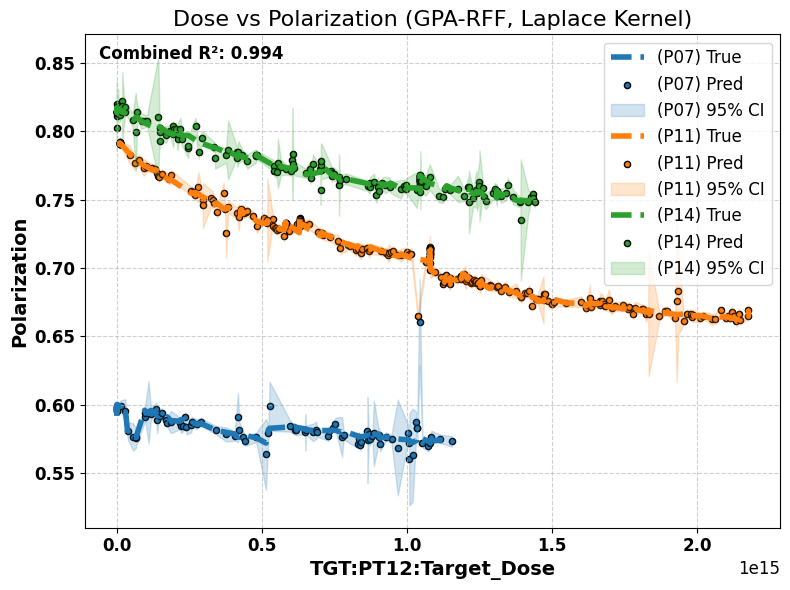

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct

# ---- Your exact formatting ----
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# -------------------------------
# 1. Load and preprocess data
# -------------------------------
file_path = '/Users/monibor/Desktop/AIOP Target Optimization/Paper/Figures/Updated_figures_feb17/GPA/gpa_rff_LAPLACE_Nelder-Mead_test_20260218_095927.csv'
df_all = pd.read_csv(file_path)
df_all["start_time"] = pd.to_datetime(df_all["start_time"], errors="coerce")

sample_dfs = {
    sid: df_sample.sort_values(by="start_time").reset_index(drop=True)
    for sid, df_sample in df_all.groupby("SampleID")
}

samples_to_plot = ["(P07)", "(P11)", "(P14)"]
colors = ["tab:blue", "tab:orange", "tab:green"]

# -------------------------------
# 2. Dose vs Polarization Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(8,6))

r2_values = {}

for sample_id, color in zip(samples_to_plot, colors):
    df = sample_dfs[sample_id].sort_values("TGT:PT12:Target_Dose")

    r2_values[sample_id] = r2_score(df["y_true"], df["y_pred"])

    ax.plot(df["TGT:PT12:Target_Dose"],
            df["y_true"],
            '--',
            linewidth=4,
            color=color,
            label=f"{sample_id} True")

    ax.scatter(df["TGT:PT12:Target_Dose"],
               df["y_pred"],
               color=color,
               edgecolor='k',
               s=20,
               marker="o",
               label=f"{sample_id} Pred")

    ax.fill_between(df["TGT:PT12:Target_Dose"],
                    df["y_pred"] - 1.96*df["y_std"],
                    df["y_pred"] + 1.96*df["y_std"],
                    color=color,
                    alpha=0.2,
                    label=f"{sample_id} 95% CI")

# Combined R²
combined_df = df_all[df_all["SampleID"].isin(samples_to_plot)]
combined_r2 = r2_score(combined_df["y_true"], combined_df["y_pred"])

# ---- Labels & Title ----
ax.set_xlabel("TGT:PT12:Target_Dose", fontweight='bold')
ax.set_ylabel("Polarization", fontweight='bold')
ax.set_title("Dose vs Polarization (GPA-RFF, Laplace Kernel)")

ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="upper right")

# ---- Bold tick labels (exactly as you requested) ----
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

# ---- R² annotation ----
ax.text(0.02, 0.95,
        f"Combined R²: {combined_r2:.3f}",
        transform=ax.transAxes,
        ha='left',
        fontsize=12,
        fontweight='bold',
        color='black')

plt.tight_layout()
plt.show()


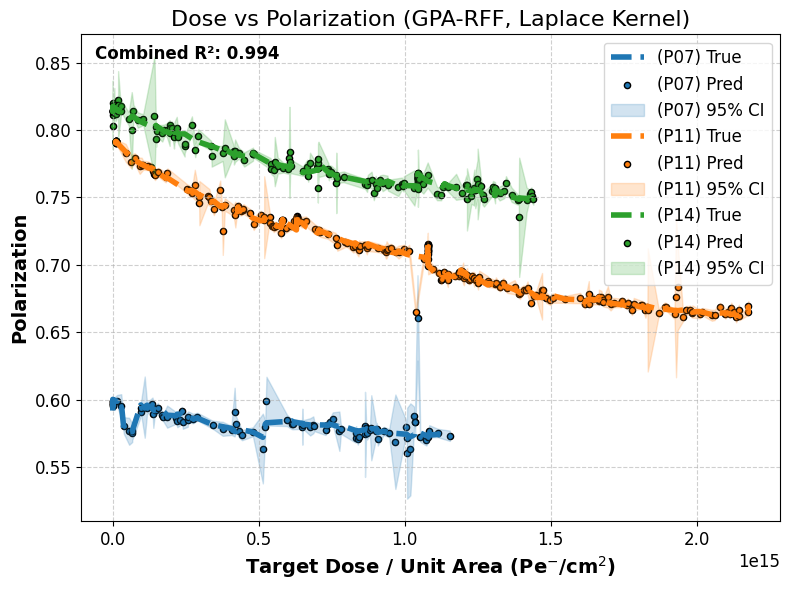

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import uncertainty_toolbox as uct
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})

# -------------------------------
# 1. Load and preprocess data
# -------------------------------
file_path = '/Users/monibor/Desktop/AIOP Target Optimization/Paper/Figures/Updated_figures_feb17/GPA/gpa_rff_LAPLACE_Nelder-Mead_test_20260218_095927.csv'
df_all = pd.read_csv(file_path)
df_all["start_time"] = pd.to_datetime(df_all["start_time"], errors="coerce")

# Separate and sort by SampleID
sample_dfs = {sid: df_sample.sort_values(by="start_time").reset_index(drop=True)
              for sid, df_sample in df_all.groupby("SampleID")}

# Choose samples and assign colors
samples_to_plot = ["(P07)", "(P11)", "(P14)"]
colors = ["tab:blue", "tab:orange", "tab:green"]

# -------------------------------
# 2. Dose vs Polarization Plot
# -------------------------------
plt.figure(figsize=(8,6))
r2_values = {}

for sample_id, color in zip(samples_to_plot, colors):
    df = sample_dfs[sample_id].sort_values("TGT:PT12:Target_Dose")
    
    # Compute R²
    r2_values[sample_id] = r2_score(df["y_true"], df["y_pred"])
    
    # Plot true values
    plt.plot(df["TGT:PT12:Target_Dose"], df["y_true"], '--', linewidth=4, color=color, label=f"{sample_id} True")
    
    # Plot predicted values
    plt.scatter(df["TGT:PT12:Target_Dose"], df["y_pred"], color=color, edgecolor='k', s=20, marker="o", label=f"{sample_id} Pred")
    
    # Plot 95% confidence interval
    plt.fill_between(df["TGT:PT12:Target_Dose"],
                     df["y_pred"] - 1.96*df["y_std"],
                     df["y_pred"] + 1.96*df["y_std"],
                     color=color, alpha=0.2, label=f"{sample_id} 95% CI")

# Combined R²
combined_df = df_all[df_all["SampleID"].isin(samples_to_plot)]
combined_r2 = r2_score(combined_df["y_true"], combined_df["y_pred"])
for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

# plt.xlabel("Target Dose / Unit Area (Pe^{-}/cm^{2}) ",fontweight='bold')
plt.xlabel(r"Target Dose / Unit Area (Pe$^{-}$/cm$^{2}$)", fontweight='bold')

plt.ylabel("Polarization",fontweight='bold')
plt.title("Dose vs Polarization (GPA-RFF, Laplace Kernel)")
plt.grid(True, linestyle="--", alpha=0.6)
# plt.ylim(0.2, 1.2)
plt.legend(loc="upper right")

# Add R² values

plt.text(0.02, 0.95, f"Combined R²: {combined_r2:.3f}", transform=plt.gca().transAxes,
         ha='left', fontsize=12, fontweight='bold', color='black')
plt.tight_layout()
plt.show()



In [8]:
combined_df

,SampleID,scaler_calc1,uwave_freq,TGT:PT12:Target_Dose,start_time,end_time,y_true,y_pred,y_std
0,(P14),7.810859,140.067371,9.952819e+14,2022-11-07 11:20:12.162020,2022-11-07 11:21:31.387435+00:00,0.758702,0.758207,0.001923
1,(P11),-0.006842,140.098719,7.061887e+14,2022-10-10 06:48:53.509504,2022-10-10 06:50:12.725973+00:00,0.724569,0.724631,0.001626
2,(P07),4.108585,140.162253,1.389136e+14,2022-08-24 22:09:25.154088,2022-08-24 22:10:44.370115+00:00,0.592212,0.588930,0.005072
3,(P11),7.846612,140.116029,4.375670e+14,2022-10-09 18:12:45.145124,2022-10-09 18:14:04.374646+00:00,0.740472,0.740007,0.001798
4,(P07),4.007062,140.156533,4.340619e+14,2022-08-25 02:48:00.990313,2022-08-25 02:49:20.198398+00:00,0.577465,0.576354,0.002520
...,...,...,...,...,...,...,...,...,...
557,(P14),-0.002869,140.059484,1.045291e+15,2022-11-07 12:19:37.297840,2022-11-07 12:20:56.528075+00:00,0.758252,0.760295,0.000726
558,(P11),6.995365,140.074660,1.633036e+15,2022-10-11 03:30:30.591625,2022-10-11 03:31:49.804941+00:00,0.674928,0.671172,0.001454
559,(P11),-0.009049,140.100546,6.306428e+14,2022-10-10 03:07:04.466198,2022-10-10 03:08:23.680674+00:00,0.734554,0.731067,0.000648
560,(P11),0.000441,140.100843,6.306433e+14,2022-10-09 23:51:39.925651,2022-10-09 23:52:59.138652+00:00,0.730773,0.731867,0.000724


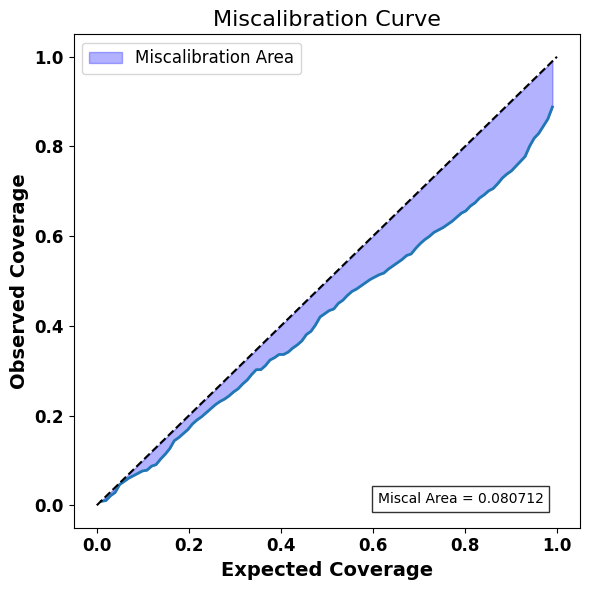

R²: 0.9943296664119647
Miscalibration area: 0.08071174377224198


In [9]:

# ------------------------
# EXACT Plot Style You Requested
# ------------------------
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})
# ------------------------
# 11. Miscalibration Curve
# ------------------------
def draw_miscalibration_curve(pred_mean, pred_std, y_true, n_bins=100):

    p_exp = np.linspace(0.01, 0.99, n_bins)
    p_obs = []

    for p in p_exp:
        z = norm.ppf((1 + p) / 2.0)
        inside = np.abs(y_true - pred_mean) <= z * pred_std
        p_obs.append(np.mean(inside))

    p_obs = np.array(p_obs)

    miscal = np.mean(np.abs(p_obs - p_exp))  # unchanged

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.plot(p_exp, p_obs, linewidth=2)
    ax.plot([0, 1], [0, 1], "k--")

    ax.fill_between(
        p_exp,
        p_obs,
        p_exp,
        color="blue",
        alpha=0.3,
        label="Miscalibration Area"
    )

    ax.set_xlabel("Expected Coverage",fontweight='bold')
    ax.set_ylabel("Observed Coverage",fontweight='bold')
    ax.set_title("Miscalibration Curve")
    ax.legend()

    ax.text(
        0.60, 0.05,
        f"Miscal Area = {miscal:.6f}",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8)
    )

    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    plt.tight_layout()
    plt.show()

    return miscal


miscal = draw_miscalibration_curve(
    combined_df["y_pred"].values, combined_df["y_std"].values, combined_df["y_true"].values
)

print("R²:", combined_r2)
print("Miscalibration area:", miscal)


